# Week 4: Distribution Fitting
Distribution Fitting is an essential tool in Wind Energy Analysis. Inferring the properties of the distribution of wind, turbulence and failure behaviour aid us with planning, optimisation and risk quanitification.

This week's content will cover:
* Distribution Fitting using Maximum Likelihood Estimation
* Goodness of Fit Criteria

This tutorial will follow on fitting and inferring information using these two distributions. If you need further revision on these distributions and their properties and parameters - please review Week 2's content [here](https://github.com/kaiyaraby/wind_energy_analytics_ke/tree/main/Statistics/Week%201).

| Distribution | Parameters | Symmetric | Domain | Examples |
|--------------|--------------|--------------|--------------|--------------|
| Weibull | $A, \ k$ | Non-symmetric | Positive-only| Mean wind speed, Failure time|
| Exponential | $\lambda$ | Non-symmetric | Positive-only| Constant failure|


## 1: Maximum Likelihood Estimation

You may recall from Week 2 that a Probability Density Function of a point, $x$, describes the *relative likelihood* of observing $x$.
Maximum Likelihood Estimation reverse engineers this concept, using observed data, $X=[x_1, x_2, \cdots, x_n]$, to identify the *most likely* form of the Probability Density Function given the data we have.

### 1.1: Exponential Distribution
Let's first look at fitting to a single parameter, $\lambda$, for the exponential distribution. You may recall this distribution is often used to describe failure times of a constant-failure rate (common in electrical components). So in this case, let's imagine our observed data are a series of failure times $T_{failure} = [t_1, t_2, \cdots, t_n]$.

The relative likelihood of a single one of these times is 
$$f(t_i) = \lambda e^{-\lambda t_i}.$$

Assuming failure events are *independent*, we can use the multiplicative property of probability: that the probability of two independent events occuring is the product of the probability of each independent event occurring, and say that the relative likelihood of two of these times both occurring is
$$f(t_i \&t_j) = \lambda e^{-\lambda t_i} \cdot \lambda e^{-\lambda t_j},$$
and this follows for every single observation we have made
$$f(t_1 \& t_2 \&\cdots\&t_n) = \lambda e^{-\lambda t_1} \lambda e^{-\lambda t_2}\cdots\lambda e^{-\lambda t_n}.$$

We can simplify first the left-hand-side of this equation, by inferring that all observations $t_1, t_2,\cdots,t_n$ in $T$ occurring is equivalent to $T$ occurring. Secondly we can simplify the right-hand-side of this equation using *product notation*. In mathematics it is common to use the notation
$$\Pi_{i=1}^{m} g(x_i)=g(x_1)g(x_2)\cdots g(x_m),$$ to mean the product of a function of $x_i$ for every integer value of $i$ between 1 and $m$.
Here, we may write
$$f(T) = \prod^n_{i=1}\lambda e^{-\lambda t_i}.$$
Since, the $\lambda$ product term is always the same, we can pull it out to get
$$f(T) = \lambda^n\prod^n_{i=1}e^{-\lambda t_i},$$
since we are equivalently multiplying by $\lambda$ $n$ times.

We now have an equation describing the overall likeliness of the observations given our parameter $\lambda$, and we want to infer the *most likely* value of $\lambda$. This value is going to be the *argument max*, or **argmax**, meaning the value of $\lambda$ which maximises the value of the function
$$\lambda_{MLE}=argmax\left[\lambda^n\prod^n_{i=1}e^{-\lambda t_i}\right].$$
With a single parameter, we can often explore a range of values, and visually identify the maximising value. 
Let's introduce our set of observations below as

In [ ]:
T = [1,1,3,4,4,5,5,6,6,7,7,7,8,8,10,10,12,23,24,25,25,25,26,27,27,27,28,28,28,28,28,29,29,29,30,30]

A sensible starting value for $\lambda$ is 0, since $\lambda$ must be positive. A sensible upper limit to explore for $\lambda$ is generally $\frac{2}{\hat{u}}$ (half the mean of the data). Since $\lambda$ should be equivalent to the inverse of the true mean, i.e. $\frac{1}{\mu}$, this gives an upper limit of double the estimated value to allow leeway for estimation or sampling bias. In this case that is equivalent to $$\frac{2}{17}=2\cdot 0.058 \approx 0.1.$$ We generally aim for at least 100 explored points (and where possible/needed around 10,000) between the start and end value to capture changes between lower and upper limit. In this case that corresponds to steps of 0.001.
We can estimate the likelihood at each of these steps using the loop structures we learnt last week. You can review the content [here](https://github.com/kaiyaraby/wind_energy_analytics_ke/tree/main/Python/Week%203%20-%20Control%20Flow).

In [54]:
likelihood = []
l = 0
while l<0.1:
    lik = l**len(T)
    for t in T:
        lik *= np.exp(-l*t)
    likelihood.append(lik)
    l += 0.001

Plotting the results below we can identify the argmax as $\lambda=0.058$.
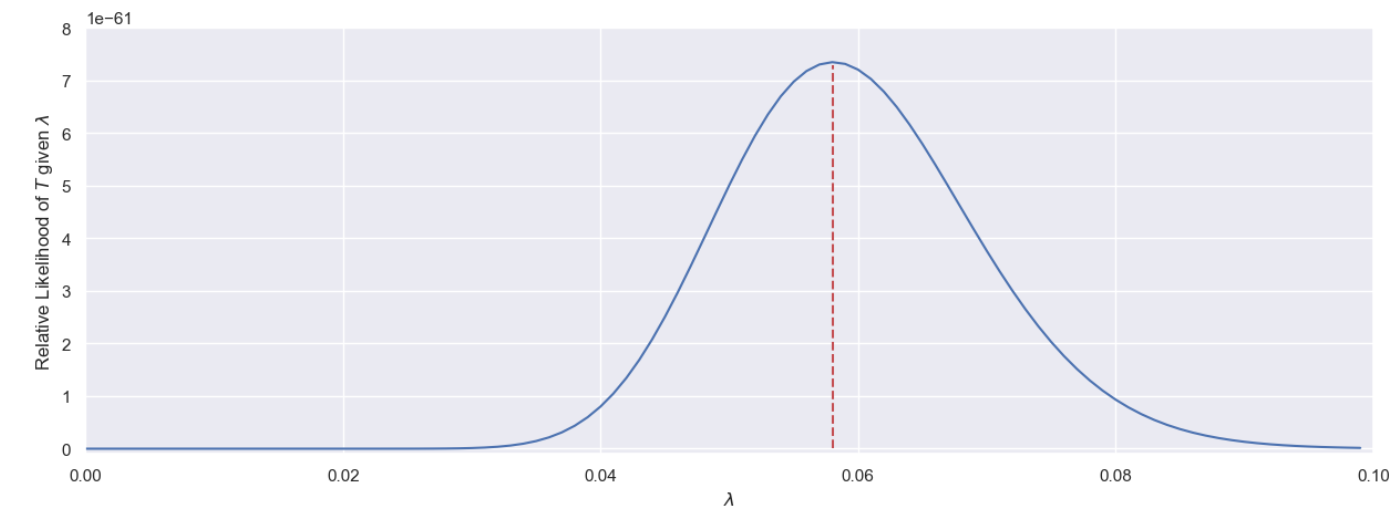

#### Exercise 1.1
Complete the code below to calculate the sample mean - write code to check if this value aligns with our estimate for $\lambda$?

(Hint: Remember that we expect $\lambda$ to be $\frac{1}{\mu}$, where $\mu$ is the mean)

In [71]:
total = 0

# Your code here

sample_mean = total/len(T)

We should see that the sample mean aligns well with our graphically estimated parameter. We therefore, have two very easy ways to estimate $\lambda$ when we have observations available. However, not all distributions are this easy! Let's look at a more complicated example.

### 1.2: Weibull Distribution

The Weibull Distribution is also commonly used to model failure rates, however it comes with two new complexities that make it much more difficult to fit than the Exponential distribution
* The Weibull distribution has a 2-dimensional parameter space ($A$ and $k$) - we can't assess it visually in the same way
* Unlike the Exponential distribution, we expect failure behaviour to *change with time*, therefore we have to incorporate 'future' failures which have not yet happened.


#### 1.2.1: Solving in the Two-Parameter Space
To address the first problem, let's look at how having two parameters changes our likelihood equation. Let's assume our failure observations are the same, $T=[t_1, t_2, \cdots, t_n]$. The relative likelihood of these observations under the Weibull distribution function, given $A$ and $k$ is
$$L(T)=\prod^n_{i=1}\frac{k}{A}\left(\frac{t_i}{A}\right)^{k-1}e^{-\left(\frac{t_i}{A}\right)^k},$$
similarly we can pull any unchanging parameters out to give
$$L(T)=\frac{k}{A}\frac{1}{A^{k-1}}\prod^n_{i=1}t_i^{k-1}e^{-\left(\frac{t_i}{A}\right)^k}$$
$$=\frac{k}{A^k}\prod^n_{i=1}t_i^{k-1}e^{-\left(\frac{t_i}{A}\right)^k}.$$

Since there are two parameters, to solve this graphically we would need a three-dimensional space, which is hard to plot and visualise in Python (although there are ways to do so!). It is easier to do this *analytically*.

It is generally considered difficult to optimise the product form of the Likelihood estimator, and usually more practical to take the natural logarithm of this equation, known as the *log-likelihood function*, $l(t)$. Since the natural logarithm is positive monotonic, it increases wherever the likelihood function increases, as such the maximum and minimum points of the log-likelihood function are the same set of points as for the original Likelihood function.
$$\begin{align}
l(T)&=\log\left(\frac{k}{A^k}\prod^n_{i=1}t_i^{k-1}e^{-\left(\frac{t_i}{A}\right)^k}\right)\\
&= \log(k)-k\log(A)+\sum^n_{i=1}\left[(k-1)\log(t)-\left(\frac{t_i}{A}\right)^k\right].
\end{align}$$

Traditionally, finding the maximising parameters for this equation would be carried out using differentiation to identify *stationary points*. Differentiating an equation, with respect to a variable, gives the rate of change respective to the change in that variable. Variable points maximising (or minimising) the function should give a rate of change of 0. It would then be possible to identify the optimising parameter vector $$\Omega=[A, k]$$ which resulted in the highest log-likelihood, and therefore the highest Likelihood.

However, it is more common in Python code to use optimisation techniques which instead try to find values which minimise the negative log-likelihood. We will go through some of these optimisation strategies later in the course, but most of the optimisation we do in Python (especially as beginners) is carried out by preexisting functions and packages so we do not have to do the maths ourselves!

#### 1.2.2: Incorporating 'censored data'

Censored data is data where some, or all, of the information is unknown. In the context of failure times there are three types of censored data:
* **Right-censored data:** The true failure time lies to the *right* of the time we know. For example, if we have a 20 year old farm and some component have not yet failed we know that their failure time is greater than 20 years, but we don't know when. The failure time lies to the *right* of 20 years on the $x$-axis.
* **Left-censored data:** The true failure time lies to the *left* of the time we know. For example, if we buy a farm that is 10 years old and we have a component that we know has been replaced due to failure but we don't know when, we know that the failure time must be less than 10 years. The failure time lies to the *left* of 10 years on the $x$-axis.
* **Interval censored data:** The true failure time lies within an *interval*. For example, a farm was bought by company A at 10 years site age, and resold to us at 15 years site age. During the time it was owned by company A, a component was replaced due to failure, so the failure time must be between 10 and 15 years, but we don't know exactly when we just know it lies in that interval.

First looking at right-censoring, we wish to consider the likelihood of an event *not* having occurred. This is the probability that the event time occurs later than the observed time. This is equivalent to 
$$L(t_{rc,1}; A,k)=1-F(t_{rc,1})=1-\left(1-e^{-At_{rc,1}^k}\right)=e^{-At_{rc,1}^k},$$
where $F(t_{rc,1})$ is the Weibull Cumulative Density Function (i.e. the probability of failure occurring between time 0 and time $t_{rc,1}$). 1 minus this probability gives the probability of failure occurring at any other time (i.e. any time later than $t_{rc,1}$).
We can combine all right-censor times, $T_{rc}=[t_{rc,1}, t_{rc,2},\cdots, t_{rc,C_{r}}]$, as
$$L(T_{rc};A,k) = \prod^{C_r}_{i=1}e^{-At_{rc,i}^k}.$$
For left censoring, we wish to consider the likelihood of an event having occurred before this time. This is equivalent just to the CDF.

$$L(t_{lc,1}; A,k)=F(t_{lc,1})=1-e^{-At_{lc,1}^k},$$

combining to give

$$L(T_{lc};A,k) = \prod^{C_l}_{i=1}1-e^{-At_{lc,i}^k}.$$

Finally, for interval censored points, we want to consider the likelihood of an event occurring between two points, this is the integral of the PDF between these two values
$$L(t_{lower, 1}, t_{upper,1}); A,k)=\int^{t_{upper,1}}_{t_{lower,1}}\frac{k}{A}\left(\frac{t}{A}\right)^{k-1}e^{-\left(\frac{t}{A}\right)^k} dt,$$
which combines as
$$L(T_{ic};A, k) = \prod^{C_i}_{i=1} \int^{t_{upper,i}}_{t_{lower,i}}\frac{k}{A}\left(\frac{t}{A}\right)^{k-1}e^{-\left(\frac{t}{A}\right)^k} dt.$$
We now multiply all of our data information together: uncensored, left censored, right censored and interval censored.
$$\begin{align}
L(T_{all};A,k) &= L(T)\cdot L(T_{rc}) \cdot L(T_{lc}) \cdot L(T_{ic})\\
&=\left(\frac{k}{A^k}\prod^n_{i=1}t_i^{k-1}e^{-\left(\frac{t_i}{A}\right)^k}\right) \cdot \left(\prod^{C_r}_{i=1}e^{-At_{rc,i}^k}\right) \cdot \left(\prod^{C_l}_{i=1}1-e^{-At_{lc,i}^k}\right) \cdot \left(\prod^{C_i}_{i=1} \int^{t_{upper,i}}_{t_{lower,i}}\frac{k}{A}\left(\frac{t}{A}\right)^{k-1}e^{-\left(\frac{t}{A}\right)^k} dt\right).
\end{align}
$$
Optimizing this equation in terms of $A$ and $k$ will now give us optimal parameters which account for *all* data and observations. This might be a very intimidating equation, but we don't need to solve it ourselves! Here at Nadara we already have distribution fitting code, which we will cover later on, with functionality to run all these equations - all you need to do as a user is feed in our data and specify what kind of censoring we are using. This is helpful background statistics, but you don't need to understand the maths to be able to distribution fit!

### 2: Comparing Goodness of Fit

For some data, we won't know what the most appropriate distribution is. For example, if we don't know whether failure rate is constant or changing with time, we might want to consider and compare both the Exponential *and* Weibull distribution. Since we already have a measure of likelihood from our fitting process, this is the easiest way to compare which distribution is the *most likely* given the data. *Likelihood comparison* is a very commonly used measure, and if 'goodness-of-fit' in terms of likelihood is the only important factor then this is a great easy way to decide which distribution to use. The one concern with this measure is it can lead to *overfitting*. This is where we fit a pattern extremely closely to the data, but it does not generalise well to the overall population because we have inferred random patterns/variation in our dataset to be features of the true population behaviour. To prevent this we have two other key measures of goodness-of-fit which penalise for model complexity:

* **Akaike Information Criterion (AIC):** $$2p-2\hat{l},$$ where $\hat{l}$ is the maximised log-likelihood, and $p$ it the number of estimated parameters (e.g. 2 for the Weibull distribution and 1 for the Exponential distribution). Comparing AIC scores, we put preference on lowest score, penalising for number of parameters and rewarding high log-likelihood. The AIC tries to identify the model that best *describes* an unknown true population which is not theorised to be amongst the candidate models.
* **Bayesian Information Criterion (BIC):** $$p \log(n)-2\hat{l},$$ where $n$ is the number of data points. As the data set gets larger, the penalisation of the number of parameters also increases. For sample sizes greater than 7, BIC score penalises complexity more than AIC score. BIC comes from *Bayesian Statistics*, this means it tries to identify the *true* model for a given set of observations.

BIC tends to be described as the "better" of the two options in terms of model recovery, as AIC tends to produce overfitted models that describe the observed data better, whereas BIC tends to better correct for this and produce simpler models closer to true distribution. This makes sense when we consider that AIC is working to best describe what we have observed, and BIC aims to recreate what is true. There are however, many advantages and disadvantages to both and it is always best to assess all three criteria (log-likelihood, AIC and BIC) and see how all three compare across the tested models.

There are additionally many *goodness-of-fit tests* which rely on *hypothesis testing*. These will be covered in Week 10.